In [2]:
# 1m
#Install required packages
!pip install kagglehub torch torchvision pydicom opencv-python matplotlib pandas

# Import libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import kagglehub
import pydicom
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import time

# Verify GPU
!nvidia-smi
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    print("WARNING: GPU not available. Training will be slow. Go to Runtime > Change runtime type > GPU and restart.")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [3]:
# 0s
#Custom Dataset class
class BrainCTDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            if img_path.lower().endswith('.dcm'):
                dcm = pydicom.dcmread(img_path)
                image = dcm.pixel_array.astype(float)
                window_center = 40
                window_width = 80
                min_value = window_center - window_width // 2
                max_value = window_center + window_width // 2
                image = np.clip(image, min_value, max_value)
                if len(image.shape) == 2:
                    image = np.stack([image] * 3, axis=-1)
            else:
                image = cv2.imread(img_path)
                if image is None:
                    raise ValueError(f"Failed to load image: {img_path}")
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
            image = image.astype(np.float32)
            if self.transform:
                image = self.transform(torch.from_numpy(image).permute(2, 0, 1))
            return image, label
        except Exception as e:
            print(f"Error processing image {img_path}: {str(e)}")
            return None, None

# Load dataset
def load_dataset(base_path, max_samples_per_class=100, random_seed=42):
    np.random.seed(random_seed)
    image_paths = []
    labels = []
    aneurysm_path = os.path.join(base_path, 'aneurysm')
    if os.path.exists(aneurysm_path):
        aneurysm_files = [os.path.join(aneurysm_path, f) for f in os.listdir(aneurysm_path)
                         if f.endswith(('.jpg', '.dcm'))]
        n_aneurysm = min(len(aneurysm_files), max_samples_per_class)
        selected_aneurysm = np.random.choice(aneurysm_files, n_aneurysm, replace=False)
        image_paths.extend(selected_aneurysm)
        labels.extend([1] * n_aneurysm)
    other_files = []
    for category in ['tumor', 'cancer']:
        category_path = os.path.join(base_path, category)
        if os.path.exists(category_path):
            other_files.extend([os.path.join(category_path, f) for f in os.listdir(category_path)
                               if f.endswith(('.jpg', '.dcm'))])
    n_other = min(len(other_files), max_samples_per_class)
    selected_other = np.random.choice(other_files, n_other, replace=False)
    image_paths.extend(selected_other)
    labels.extend([0] * n_other)
    return image_paths, labels

In [7]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
print("Loading dataset...")
dataset_path = kagglehub.dataset_download("shuvokumarbasakbd/brain-ct-medical-imaging-colorized-dataset")
base_path = os.path.join(dataset_path, 'Computed Tomography (CT) of the Brain', 'dataset')

train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

# Load image paths and labels from existing folders
train_paths, train_labels = load_dataset(train_dir, max_samples_per_class=100)
test_paths, test_labels = load_dataset(test_dir, max_samples_per_class=100)

# Create datasets
train_dataset = BrainCTDataset(train_paths, train_labels, transform=transform)
test_dataset = BrainCTDataset(test_paths, test_labels, transform=transform)

# Create data loaders
batch_size = 64 if torch.cuda.is_available() else 16
num_workers = 4 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


Loading dataset...


In [8]:
# 0s
# Define model with frozen layers
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.vgg16 = models.vgg16(weights='IMAGENET1K_V1')
        for param in self.vgg16.features.parameters():
            param.requires_grad = False
        in_feats = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_feats, 2)
    def forward(self, x):
        x = self.vgg16(x)
        return x

In [9]:
# 12m
# Initialize model, loss, and optimizer
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

# Training with progress
epochs = 5
print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    for i, batch in enumerate(train_loader):
        inputs, labels = batch
        if inputs is None:
            continue
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        print(f"[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / (i + 1):.4f}, Time: {time.time() - start_time:.2f}s")
    print(f"Epoch {epoch + 1} completed in {time.time() - start_time:.2f}s")

# Save the trained model
torch.save(model.state_dict(), 'model.pth')
print("Model saved as 'model.pth'")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 129MB/s]


Starting training...
[Epoch 1, Batch 1] Loss: 0.7569, Time: 15.23s
[Epoch 1, Batch 2] Loss: 0.7243, Time: 28.51s
[Epoch 1, Batch 3] Loss: 0.7276, Time: 41.89s
[Epoch 1, Batch 4] Loss: 0.7105, Time: 55.27s
[Epoch 1, Batch 5] Loss: 0.6695, Time: 68.46s
[Epoch 1, Batch 6] Loss: 0.6717, Time: 81.73s
[Epoch 1, Batch 7] Loss: 0.6570, Time: 94.85s
[Epoch 1, Batch 8] Loss: 0.6592, Time: 107.92s
[Epoch 1, Batch 9] Loss: 0.6496, Time: 121.11s
[Epoch 1, Batch 10] Loss: 0.6356, Time: 134.34s
[Epoch 1, Batch 11] Loss: 0.6377, Time: 147.63s
[Epoch 1, Batch 12] Loss: 0.6244, Time: 160.87s
[Epoch 1, Batch 13] Loss: 0.6162, Time: 168.03s
Epoch 1 completed in 168.03s
[Epoch 2, Batch 1] Loss: 0.4595, Time: 13.13s
[Epoch 2, Batch 2] Loss: 0.5298, Time: 26.27s
[Epoch 2, Batch 3] Loss: 0.5259, Time: 39.42s
[Epoch 2, Batch 4] Loss: 0.5191, Time: 52.46s
[Epoch 2, Batch 5] Loss: 0.5153, Time: 65.64s
[Epoch 2, Batch 6] Loss: 0.5054, Time: 78.76s
[Epoch 2, Batch 7] Loss: 0.4940, Time: 91.84s
[Epoch 2, Batch 8] L

In [10]:
# 2m 43s
#Initialize model
model = CNNModel().to(device)

# Load saved model
model.load_state_dict(torch.load('model.pth'))
model.eval()
print("Loaded saved model 'model.pth'")

# Evaluate accuracy
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            inputs, labels = batch
            if inputs is None:
                continue
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total if total > 0 else 0
    return accuracy

train_accuracy = evaluate_model(model, train_loader)
test_accuracy = evaluate_model(model, test_loader)
print(f"\nTraining Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Loaded saved model 'model.pth'

Training Accuracy: 99.00%
Test Accuracy: 100.00%


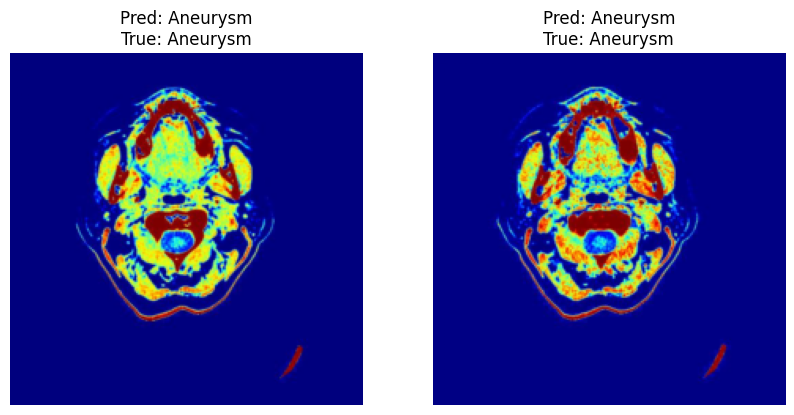

In [11]:
# 12s
# Visualize predictions (limited to 2 images)
def visualize_predictions(model, loader, num_images=2):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(10, 5))
    with torch.no_grad():
        for inputs, labels in loader:
            if inputs is None:
                continue
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                img = inputs[i].cpu().permute(1, 2, 0).numpy()
                img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                img = np.clip(img, 0, 1)
                plt.subplot(1, num_images, images_shown + 1)
                plt.imshow(img)
                plt.title(f"Pred: {'Aneurysm' if preds[i].item() == 1 else 'Non-aneurysm'}\nTrue: {'Aneurysm' if labels[i].item() == 1 else 'Non-aneurysm'}")
                plt.axis('off')
                images_shown += 1
            if images_shown >= num_images:
                break
    plt.show()

visualize_predictions(model, test_loader)

Running test execution...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model initialized on device: cpu
Analysis started at 2025-05-26 13:28:45 UTC
Analysis requested by: krooldonutz
Analyzing the image with SHAP...


  0%|          | 0/68 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:50, 50.11s/it]               


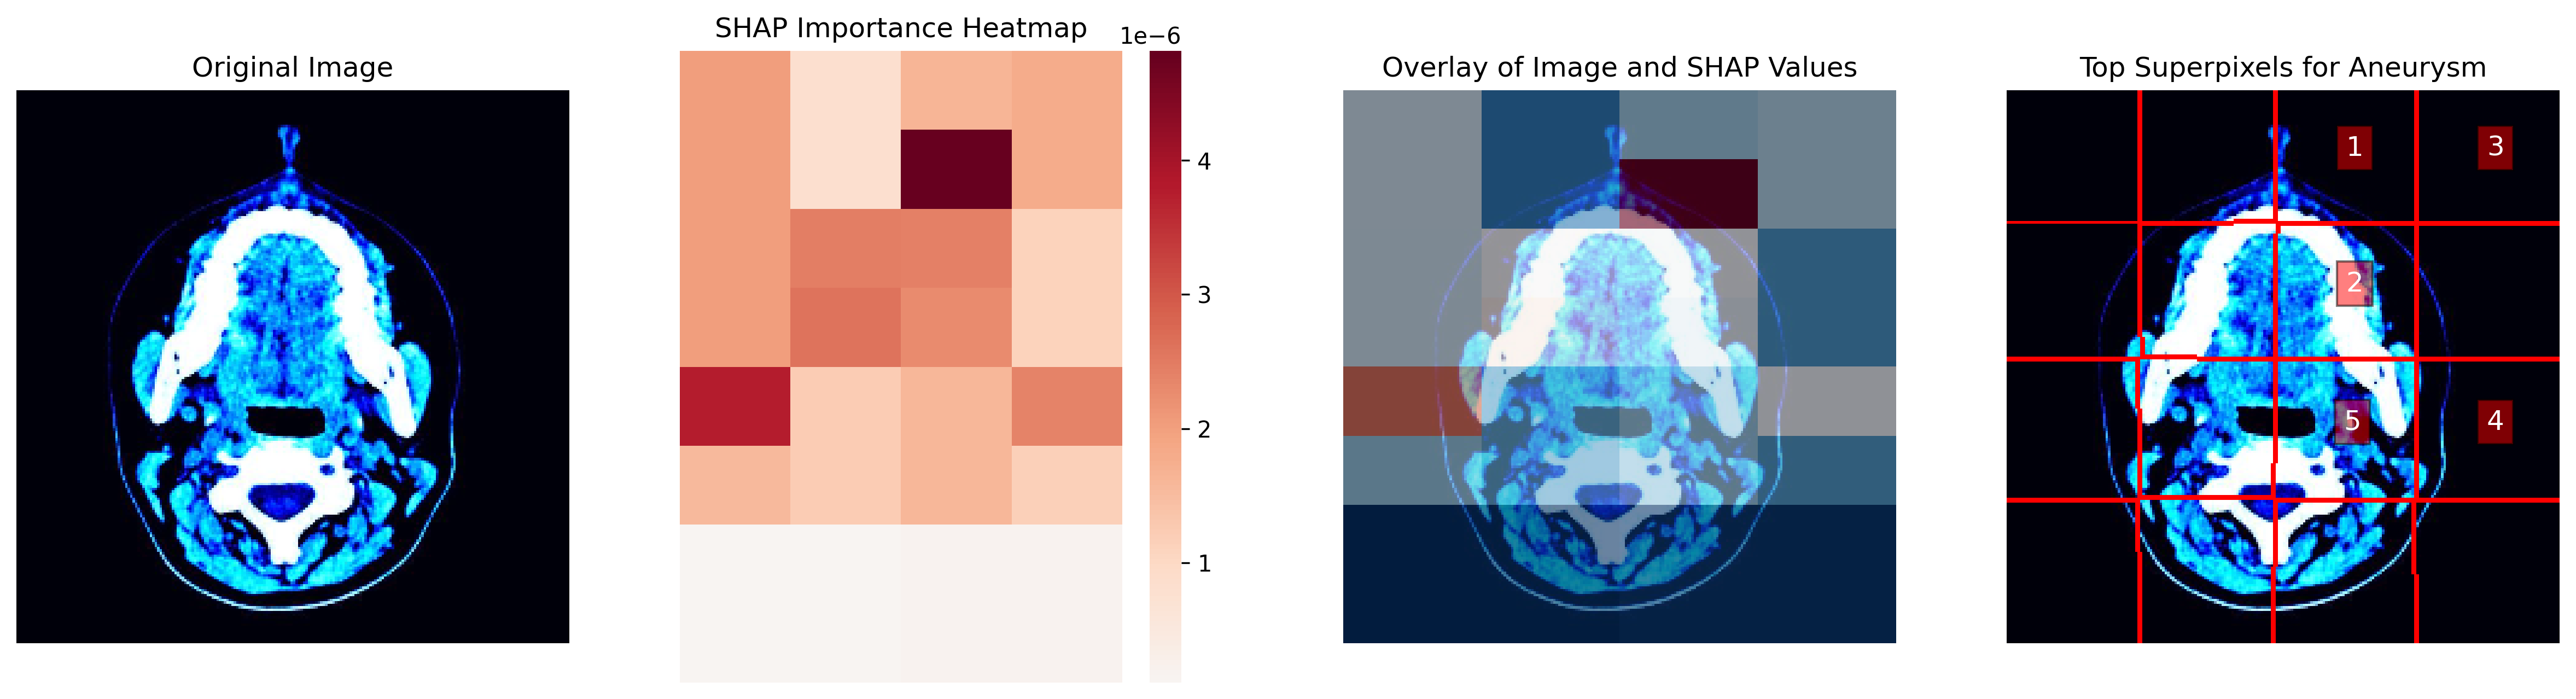

Analysis Result:
{'prediction': {'result': 'no aneurysm detected', 'confidence': 0.500572681427002, 'confidence_level': 'low'}, 'analysis': {'most_important_quadrant': 'upper_right', 'quadrant_scores': {'upper_left': 1.847950288658442e-06, 'upper_right': 2.120960453132383e-06, 'lower_left': 1.0308547049988898e-06, 'lower_right': 9.294977446473171e-07}, 'relative_importances': {'upper_left': 0.31166609222664104, 'upper_right': 0.3577106268777962, 'lower_left': 0.17385882051713228, 'lower_right': 0.15676446037843053}, 'stability_score': 0.3111480763385922, 'importance_score': 1.482315797859258e-06, 'superpixel_analysis': {'num_superpixels': 16, 'top_superpixels': [2, 6, 3, 11, 10], 'top_shap_scores': [2.963631725095916e-06, 2.1858320171386825e-06, 1.837127519762928e-06, 1.751774609015984e-06, 1.455280616377198e-06]}}, 'metadata': {'analysis_duration': 53.35389, 'start_time': '2025-05-26T13:28:45.890449', 'end_time': '2025-05-26T13:29:39.244339'}, 'visualization': {'url': '/content/shap_o

In [17]:
# Install required packages
!pip install shap seaborn scikit-image

# Imports
import shap
import numpy as np
import torch
from torchvision import transforms, models
import requests
import cv2
from datetime import datetime
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns
import os
from skimage.segmentation import slic, mark_boundaries
from skimage.color import rgb2gray
from IPython.display import Image as IPyImage, display

# Mock CNNModel class (replace with your actual model if available)
class CNNModel(torch.nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Use VGG16 as a placeholder, matching your Colab superpixel code
        self.model = models.vgg16(pretrained=False)
        self.model.classifier[6] = torch.nn.Linear(self.model.classifier[6].in_features, 2)

    def forward(self, x):
        return self.model(x)

# Mock ShapAnalysisService class
class ShapAnalysisService:
    def __init__(self):
        import matplotlib
        matplotlib.use('Agg')  # Non-interactive backend for saving plots
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CNNModel().to(self.device)
        self.model.eval()  # Set to evaluation mode
        # Note: Model weights are not loaded; using random weights for testing
        print(f"Model initialized on device: {self.device}")

    def save_to_s3(self, image_data, user_id, image_name, request_id=None):
        """
        Mock save_to_s3 to save locally in Colab and return a file path.
        """
        try:
            output_dir = "/content/shap_outputs"
            os.makedirs(output_dir, exist_ok=True)
            output_path = os.path.join(output_dir, image_name)
            with open(output_path, 'wb') as f:
                f.write(image_data.getvalue())
            return output_path  # Return local file path instead of S3 URL
        except Exception as e:
            print(f"Error saving file: {str(e)}")
            return None

    # Paste the provided analyze_image method here
    def analyze_image(self, image_url, user_id, request_id):
        try:
            start_time = datetime.utcnow()
            print(f"Analysis started at {start_time.strftime('%Y-%m-%d %H:%M:%S')} UTC")
            print(f"Analysis requested by: krooldonutz")

            # Image loading and preprocessing
            response = requests.get(image_url)
            if response.status_code != 200:
                raise Exception("Could not download image from URL")
            image_pil = Image.open(io.BytesIO(response.content))
            image = np.array(image_pil)
            is_grayscale = len(image.shape) == 2 or (len(image.shape) == 3 and image.shape[2] == 1)
            if is_grayscale:
                if len(image.shape) == 3:
                    image = image.squeeze(-1)
                image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            else:
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_rgb = cv2.resize(image_rgb, (224, 224))
            image_normalized = (image_rgb - np.min(image_rgb)) / (np.max(image_rgb) - np.min(image_rgb) + 1e-7)
            image_normalized = image_normalized.astype(np.float32)

            # Prepare grayscale image for superpixel segmentation
            if is_grayscale:
                image_gray = cv2.resize(image, (224, 224))
                image_gray = (image_gray - np.min(image_gray)) / (np.max(image_gray) - np.min(image_gray) + 1e-7)
            else:
                image_gray = rgb2gray(image_normalized)

            # SHAP analysis
            masker = shap.maskers.Image("inpaint_telea", (224, 224, 3))
            def model_pipeline(x):
                x = torch.Tensor(x).permute(0, 3, 1, 2)
                normalize = transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
                x = torch.stack([normalize(img) for img in x])
                with torch.no_grad():
                    x = x.to(next(self.model.parameters()).device)
                    output = self.model(x)
                    probs = torch.nn.functional.softmax(output, dim=1)
                return probs.cpu().numpy()

            print("Analyzing the image with SHAP...")
            explainer = shap.Explainer(model=model_pipeline, masker=masker)
            shap_values = explainer(
                np.expand_dims(image_normalized, 0),
                max_evals=70,
                batch_size=5,
                outputs=shap.Explanation.argsort.flip[:1]
            )

            # Model prediction
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                )
            ])
            image_tensor = transform(Image.fromarray((image_normalized * 255).astype(np.uint8)))
            image_tensor = image_tensor.unsqueeze(0).to(next(self.model.parameters()).device)
            with torch.no_grad():
                output = self.model(image_tensor)
                probs = torch.nn.functional.softmax(output, dim=1)
                pred = torch.argmax(probs, dim=1).item()
                conf = probs[0][pred].item()

            # Existing SHAP analysis calculations
            shap_abs = np.abs(shap_values.values)
            mean_shap = np.mean(shap_abs, axis=(0, -1))
            if len(mean_shap.shape) > 2:
                mean_shap = np.mean(mean_shap, axis=-1)

            # Superpixel segmentation
            labels = slic(image_gray, n_segments=20, compactness=20, sigma=1, start_label=0, channel_axis=None)
            num_superpixels = np.max(labels) + 1
            shap_vals_aneurysm = shap_values.values[0, :, :, :, 0].mean(axis=2)  # Use class 0 or 1 based on pred
            shap_per_superpixel = np.zeros(num_superpixels)
            for sp in range(num_superpixels):
                mask = labels == sp
                if mask.sum() > 0:
                    shap_per_superpixel[sp] = shap_vals_aneurysm[mask].mean()
            top_indices = np.argsort(shap_per_superpixel)[-5:][::-1]
            top_shap_scores = shap_per_superpixel[top_indices].tolist()

            # Generate visualizations
            plt.figure(figsize=(20, 5))

            # Original image
            plt.subplot(1, 4, 1)
            plt.imshow(image_rgb)
            plt.title("Original Image")
            plt.axis('off')

            # SHAP heatmap
            plt.subplot(1, 4, 2)
            sns.heatmap(mean_shap, cmap='RdBu_r', center=0)
            plt.title("SHAP Importance Heatmap")
            plt.axis('off')

            # SHAP overlay
            plt.subplot(1, 4, 3)
            plt.imshow(image_rgb)
            plt.imshow(mean_shap, cmap='RdBu_r', alpha=0.6)
            plt.title("Overlay of Image and SHAP Values")
            plt.axis('off')

            # Superpixel highlight plot
            plt.subplot(1, 4, 4)
            boundary_img = mark_boundaries(image_rgb / 255.0, labels, color=(1, 0, 0))
            plt.imshow(boundary_img)
            for idx, sp in enumerate(top_indices):
                mask = labels == sp
                y, x = np.where(mask)
                if len(x) > 0 and len(y) > 0:
                    centroid = (int(np.mean(x)), int(np.mean(y)))
                    plt.text(centroid[0], centroid[1], str(idx + 1), color='white', fontsize=12,
                             bbox=dict(facecolor='red', alpha=0.5))
            plt.title("Top Superpixels for Aneurysm")
            plt.axis('off')

            # Save combined plot locally
            buf = io.BytesIO()
            plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
            buf.seek(0)
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            image_name = f'shap_analysis_{timestamp}.png'
            s3_url = self.save_to_s3(buf, user_id, image_name, request_id)
            plt.close()

            # Display the saved image
            if s3_url and os.path.exists(s3_url):
                display(IPyImage(filename=s3_url))

            # Quadrant analysis
            h, w = mean_shap.shape
            quadrants = {
                'upper_left': mean_shap[:h//2, :w//2],
                'upper_right': mean_shap[:h//2, w//2:],
                'lower_left': mean_shap[h//2:, :w//2],
                'lower_right': mean_shap[h//2:, w//2:]
            }
            quadrant_scores = {k: float(np.mean(v)) for k, v in quadrants.items()}
            most_important_quadrant = max(quadrant_scores.items(), key=lambda x: x[1])[0]
            total_importance = float(np.sum(np.abs(mean_shap)))
            relative_importances = {k: float(np.sum(np.abs(v)))/total_importance for k, v in quadrants.items()}

            end_time = datetime.utcnow()
            analysis_duration = (end_time - start_time).total_seconds()

            return {
                'prediction': {
                    'result': 'aneurysm detected' if pred == 1 else 'no aneurysm detected',
                    'confidence': float(conf),
                    'confidence_level': "high" if conf > 0.8 else "moderate" if conf > 0.6 else "low"
                },
                'analysis': {
                    'most_important_quadrant': most_important_quadrant,
                    'quadrant_scores': quadrant_scores,
                    'relative_importances': relative_importances,
                    'stability_score': float(1 - (np.std(mean_shap) / (np.mean(mean_shap) + 1e-7))),
                    'importance_score': float(np.mean(np.abs(mean_shap))),
                    'superpixel_analysis': {
                        'num_superpixels': int(num_superpixels),
                        'top_superpixels': [int(idx) for idx in top_indices],
                        'top_shap_scores': top_shap_scores
                    }
                },
                'metadata': {
                    'analysis_duration': analysis_duration,
                    'start_time': start_time.isoformat(),
                    'end_time': end_time.isoformat()
                },
                'visualization': {
                    'url': s3_url
                },
                'request_id': request_id
            }

        except Exception as e:
            return {
                'error': str(e),
                'status': 'failed'
            }

# Test the code
if __name__ == "__main__":
    print("Running test execution...")
    try:
        # Initialize the service
        service = ShapAnalysisService()

        # Test parameters
        image_url = "https://i.postimg.cc/xC5k253d/1-11.jpg"
        user_id = "test_user"
        request_id = "test_request"

        # Run analysis
        result = service.analyze_image(image_url, user_id, request_id)
        print("Analysis Result:")
        print(result)

        # If there's an error, print it and stop
        if 'error' in result:
            print(f"Error: {result['error']}")
        else:
            print("Analysis completed successfully!")
            print(f"Visualization saved at: {result['visualization']['url']}")

    except Exception as e:
        print(f"Test execution failed: {str(e)}")